# Libraries

In [1]:
import pandas as pd
import numpy as np

pd.set_option('display.max_columns', None)

In [2]:
#Bring Data

df= pd.read_excel('/content/pronta_data.xlsx')

# Data Approach

In [3]:
df.head()



,ID_Venta,Fecha_Venta,ID_Cliente,Producto,Categoría,Precio_Unitario,Cantidad,Método_Pago,Sucursal,Total_Venta
0,bdd640fb-0667-4ad1-9c80-317fa3b1799d,2025-03-04,4657,Detergente,Limpieza,20878,3,Débito,Sucursal Centro,62634
1,23b8c1e9-3924-46de-beb1-3b9046685257,2025-01-08,2535,Detergente,Limpieza,153766,1,Débito,Sucursal Norte,153766
2,bd9c66b3-ad3c-4d6d-9a3d-1fa7bc8960a9,2025-04-18,4611,Papas fritas,Snacks,146893,5,Mercado Pago,Sucursal Sur,734465
3,972a8469-1641-4f82-8b9d-2434e465e150,2025-03-13,3547,Queso cremoso,Lácteos,179063,3,Débito,Sucursal Sur,537189
4,17fc695a-07a0-4a6e-8822-e8f36c031199,2025-03-30,5333,Leche entera,Lácteos,104283,3,Efectivo,Sucursal Oeste,312849


In [4]:
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   ID_Venta         30000 non-null  object        
 1   Fecha_Venta      30000 non-null  datetime64[ns]
 2   ID_Cliente       30000 non-null  int64         
 3   Producto         30000 non-null  object        
 4   Categoría        30000 non-null  object        
 5   Precio_Unitario  30000 non-null  int64         
 6   Cantidad         30000 non-null  int64         
 7   Método_Pago      30000 non-null  object        
 8   Sucursal         30000 non-null  object        
 9   Total_Venta      30000 non-null  int64         
dtypes: datetime64[ns](1), int64(4), object(5)
memory usage: 2.3+ MB


In [5]:
df.describe()

,Fecha_Venta,ID_Cliente,Precio_Unitario,Cantidad,Total_Venta
count,30000,30000.000000,30000.000000,30000.000000,3.000000e+04
mean,2025-03-31 20:38:15.360000,5497.094600,120152.648467,3.003767,3.003997e+05
min,2025-01-01 00:00:00,1000.000000,1501.000000,1.000000,1.540000e+03
25%,2025-02-15 00:00:00,3234.000000,54011.750000,2.000000,7.921750e+04
50%,2025-04-01 00:00:00,5491.000000,118553.000000,3.000000,2.051355e+05
75%,2025-05-16 00:00:00,7754.000000,184324.750000,4.000000,4.588318e+05
max,2025-06-30 00:00:00,9999.000000,249997.000000,5.000000,1.249885e+06
std,NaN,2604.878331,73581.003060,1.409900,2.782184e+05


# I start working with the Date

In [6]:
#Convert feature into datetime
df['Fecha_Venta'] = pd.to_datetime(df['Fecha_Venta'])

In [7]:
df['Fecha_Venta']

,Fecha_Venta
0,2025-03-04
1,2025-01-08
2,2025-04-18
3,2025-03-13
4,2025-03-30
...,...
29995,2025-02-25
29996,2025-01-02
29997,2025-04-17
29998,2025-03-27


In [8]:
#I check date range
print(df['Fecha_Venta'].min())
print(df['Fecha_Venta'].max())

2025-01-01 00:00:00
2025-06-30 00:00:00


## I have six months data

# I create the temporal split

In [9]:
train_df= df[df['Fecha_Venta'] <= '2025-04-30']
test_df= df[df['Fecha_Venta'] >= '2025-05-01']

# Feature Engineering

## Target: Create dataset client-level
### First 1:

### RFM + Core Metrics

In [10]:
# RECENCY: "¿How often does the Client buy?"
snapshot_date= pd.Timestamp('2025-04-30')


In [11]:
recency = (
    train_df.groupby('ID_Cliente')['Fecha_Venta']
    .max()
    .reset_index()
)  # Group train dataset by cliente and pruchase date

recency['Recency'] = (snapshot_date - recency['Fecha_Venta']).dt.days
#Obtein data about the last client's pruchase: It menas how many days went by after their last prurchase

recency.head()

,ID_Cliente,Fecha_Venta,Recency
0,1000,2025-03-26,35
1,1001,2025-03-20,41
2,1002,2025-03-31,30
3,1003,2025-03-20,41
4,1004,2025-01-09,111


In [13]:
# FREQUENCY : “How many purchases did each customer make?”
frequency = (train_df.groupby('ID_Cliente')['ID_Venta']
             .count().reset_index()) #Group by client Id and purchase date

frequency.rename(
    columns={'ID_Venta': 'Frequency'}, #Replace 'ID_Venta' by Frecuency calculation
    inplace=True
)

frequency.head()


,ID_Cliente,Frequency
0,1000,2
1,1001,5
2,1002,2
3,1003,2
4,1004,1


In [14]:
#Monetary: "'How much money did the client spend?"
monetary = (train_df.groupby('ID_Cliente')['Total_Venta'] #Group by client Id and purchase date
    .sum()                                                #I add up the sales
    .reset_index()
)

monetary.rename(
    columns={'Total_Venta': 'Monetary'}, #Replace 'ID_Venta' by Monetary calculation
    inplace=True
)

monetary.head()

,ID_Cliente,Monetary
0,1000,920404
1,1001,1244040
2,1002,831268
3,1003,407090
4,1004,721545


In [16]:
#AVR TICKET: "Average ticker by purchase"
avg_ticket = (
    train_df.groupby('ID_Cliente')['Total_Venta'] #Group by client Id and purchase date
    .mean()                                       #Calculate mean on purchases
    .reset_index()
)

avg_ticket.rename(
    columns={'Total_Venta': 'Avg_Ticket'},      #Replace 'ID_Venta' by Average calculation
    inplace=True
)

avg_ticket.head()

,ID_Cliente,Avg_Ticket
0,1000,460202.0
1,1001,248808.0
2,1002,415634.0
3,1003,203545.0
4,1004,721545.0


# Next step 2 — MERGE FEATURES

In [17]:
customer_features = recency[['ID_Cliente', 'Recency']]

In [19]:
customer_features = customer_features.merge(
    frequency,
    on='ID_Cliente',
    how='left'
) # Merge the calculated featured on the original dataset

customer_features = customer_features.merge(
    monetary,
    on='ID_Cliente',
    how='left'
) # Merge the calculated featured on the original dataset

customer_features = customer_features.merge(
    avg_ticket,
    on='ID_Cliente',
    how='left'
)# Merge the calculated featured on the original dataset

customer_features.head()

,ID_Cliente,Recency,Frequency_x,Monetary_x,Avg_Ticket_x,Frequency_y,Monetary_y,Avg_Ticket_y
0,1000,35,2,920404,460202.0,2,920404,460202.0
1,1001,41,5,1244040,248808.0,5,1244040,248808.0
2,1002,30,2,831268,415634.0,2,831268,415634.0
3,1003,41,2,407090,203545.0,2,407090,203545.0
4,1004,111,1,721545,721545.0,1,721545,721545.0


# Next step 3 — CREATING FUTURE CVL
## May-June

In [20]:
future_clv = (
    test_df.groupby('ID_Cliente')['Total_Venta']
    .sum()
    .reset_index()
)

future_clv.rename(
    columns={'Total_Venta': 'CLV_60D'},
    inplace=True
)

future_clv.head()

,ID_Cliente,CLV_60D
0,1000,120196
1,1003,64158
2,1005,317245
3,1007,549667
4,1008,95207


# PASO 4 — MERGE TARGET

In [21]:
final_df = customer_features.merge(
    future_clv,
    on='ID_Cliente',
    how='left'
)
final_df.head()

,ID_Cliente,Recency,Frequency_x,Monetary_x,Avg_Ticket_x,Frequency_y,Monetary_y,Avg_Ticket_y,CLV_60D
0,1000,35,2,920404,460202.0,2,920404,460202.0,120196.0
1,1001,41,5,1244040,248808.0,5,1244040,248808.0,NaN
2,1002,30,2,831268,415634.0,2,831268,415634.0,NaN
3,1003,41,2,407090,203545.0,2,407090,203545.0,64158.0
4,1004,111,1,721545,721545.0,1,721545,721545.0,NaN


## VERY IMPORTANT

### Customers who did NOT purchase: Will have NaN... this is NOT an error

## It means:

### Future CLV = 0
I fix it filling the empty entries

In [22]:
final_df['CLV_60D'] = final_df['CLV_60D'].fillna(0)

# I check the final dataset


In [23]:
final_df.head()

,ID_Cliente,Recency,Frequency_x,Monetary_x,Avg_Ticket_x,Frequency_y,Monetary_y,Avg_Ticket_y,CLV_60D
0,1000,35,2,920404,460202.0,2,920404,460202.0,120196.0
1,1001,41,5,1244040,248808.0,5,1244040,248808.0,0.0
2,1002,30,2,831268,415634.0,2,831268,415634.0,0.0
3,1003,41,2,407090,203545.0,2,407090,203545.0,64158.0
4,1004,111,1,721545,721545.0,1,721545,721545.0,0.0


In [24]:
final_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8003 entries, 0 to 8002
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   ID_Cliente    8003 non-null   int64  
 1   Recency       8003 non-null   int64  
 2   Frequency_x   8003 non-null   int64  
 3   Monetary_x    8003 non-null   int64  
 4   Avg_Ticket_x  8003 non-null   float64
 5   Frequency_y   8003 non-null   int64  
 6   Monetary_y    8003 non-null   int64  
 7   Avg_Ticket_y  8003 non-null   float64
 8   CLV_60D       8003 non-null   float64
dtypes: float64(3), int64(6)
memory usage: 562.8 KB


In [25]:

final_df.describe()

,ID_Cliente,Recency,Frequency_x,Monetary_x,Avg_Ticket_x,Frequency_y,Monetary_y,Avg_Ticket_y,CLV_60D
count,8003.000000,8003.000000,8003.000000,8.003000e+03,8.003000e+03,8003.000000,8.003000e+03,8.003000e+03,8.003000e+03
mean,5477.175184,38.823691,2.489941,7.512042e+05,3.015503e+05,2.489941,7.512042e+05,3.015503e+05,3.335570e+05
std,2606.041530,31.049376,1.333716,6.004013e+05,2.034566e+05,1.333716,6.004013e+05,2.034566e+05,4.300653e+05
min,1000.000000,0.000000,1.000000,1.540000e+03,1.540000e+03,1.000000,1.540000e+03,1.540000e+03,0.000000e+00
25%,3210.500000,13.000000,1.000000,2.721165e+05,1.466900e+05,1.000000,2.721165e+05,1.466900e+05,0.000000e+00
50%,5461.000000,31.000000,2.000000,6.303740e+05,2.675110e+05,2.000000,6.303740e+05,2.675110e+05,1.476080e+05
75%,7740.500000,60.000000,3.000000,1.070618e+06,4.131015e+05,3.000000,1.070618e+06,4.131015e+05,5.424855e+05
max,9999.000000,119.000000,10.000000,4.743694e+06,1.245905e+06,10.000000,4.743694e+06,1.245905e+06,3.617726e+06


In [ ]:
final_df.shape

(8003, 6)

In [26]:
final_df.isnull().sum()

,0
ID_Cliente,0
Recency,0
Frequency_x,0
Monetary_x,0
Avg_Ticket_x,0
Frequency_y,0
Monetary_y,0
Avg_Ticket_y,0
CLV_60D,0


# I have the dataset clean and ready to work with.

# Beacuuse I'm gonna work with Regression , understanding the target distribution is CRITICAL.
## Therefor I continue with:

# STEP 1: Analyze CLV_60D

In [28]:
#STEP 1: Analyze CLV_60D
round(final_df['CLV_60D'].describe(),2)

,CLV_60D
count,8003.00
mean,333557.00
std,430065.27
min,0.00
25%,0.00
50%,147608.00
75%,542485.50
max,3617726.00


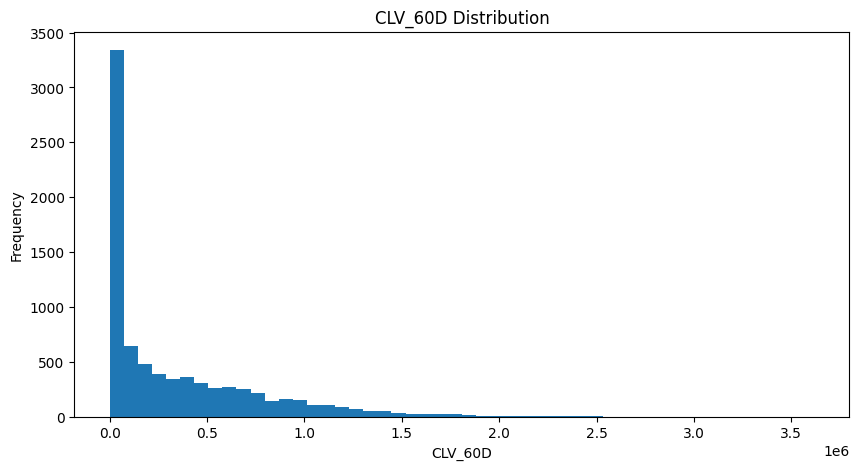

In [29]:
# Visual Check

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.hist(final_df['CLV_60D'],bins=50)

plt.xlabel('CLV_60D')
plt.ylabel('Frequency')

plt.title('CLV_60D Distribution')
plt.show()

# The TARGET FEATURE has an extremely positive skewed distribution
## Ir means:


*   Many customers with a low CLV
*   Few customers with a extremely high CLV



# VERY IMPORTANT:
## If I train the model with this conditions, it will focus on the Big Customers, affecting the model's prediction
## Therefor I will apply a Logarithmic Transformation to balance de data.

## This will reduce:

*   Skewness
*   Impact outliers
*   Extreme Variance

## Imporving


*   Stability
*   Learning
*   Performance










In [34]:
import numpy as np

final_df['Log_CLV_60D'] = np.log1p(final_df['CLV_60D'])  #log(0) it returns a error ----  but log1p(0) it works perfect

# PASO 2 — I check again

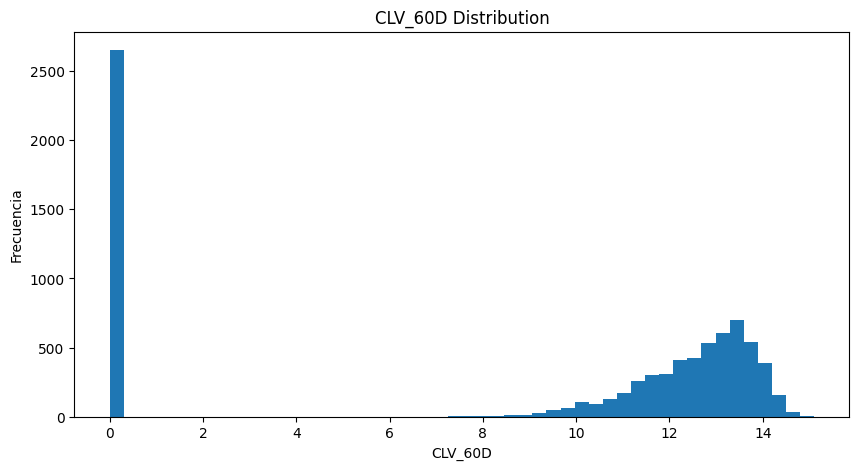

In [35]:
# Visual Cheack
plt.figure(figsize=(10, 5))
plt.hist(final_df['CLV_60D_log'], bins=50)

plt.xlabel('CLV_60D')
plt.ylabel('Frecuencia')

plt.title('CLV_60D Distribution')
plt.show()

#  What I can see here is:
## A very large group in:

**value 0**

##These are: Customers who did NOT buy in May-June
**Future CLV = 0**

## That is perfectly valid.
<br>

## This is normal in CLV.

### Because many customers: Disappear, temporarily stop buying, buy very little
<br>

# This is GOOD because:

## Now the model:

*   Doesn't get so fixated on giant outliers
*   learns more general patterns
*   tends to generalize better




# Now it's time to work with the model

## FIRST MODEL
### PROFESSIONAL BASELINE
**Random Forest Regressor**

Excellent for:

*   Tabular datasets
*   Nonlinear features
*   Initial interpretability


# STEP 3 — Separate Features and Target

In [36]:
X = final_df.drop(columns = ['ID_Cliente','CLV_60D','Log_CLV_60D'])

y = final_df['Log_CLV_60D']

# Step 4 -- Train/Test Split

In [37]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Step 5: Model Training

In [38]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
    )

rf_model.fit(X_train, y_train)


RandomForestRegressor(max_depth=10, n_estimators=200, n_jobs=-1,
                      random_state=42)

# Step 6: Predictions

In [39]:
y_pred = rf_model.predict(X_test)

# Step 7: Evaluate

In [40]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae}")
print(f"RMSE: {rmse}")
print(f"R² Score: {r2}")

MAE: 0.001146435647110542
RMSE: 0.007774227902742028
R² Score: 0.9999983147536272


# The output suspiciously optimal

In [42]:
#Quick check

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance

,Feature,Importance
7,CLV_60D_log,9.999984e-01
0,Recency,6.465189e-07
2,Monetary_x,3.009611e-07
5,Monetary_y,1.597168e-07
6,Avg_Ticket_y,1.420789e-07
1,Frequency_x,1.105888e-07
3,Avg_Ticket_x,1.089449e-07
4,Frequency_y,9.269762e-08


# There is a total leakage.

## Because: CLV_60D_log is within the FEATURES.

## And that means the model: Is seeing the correct answer while training.

### | Feature     | Importance |

    | CLV_60D_log | 0.999984   |


In [43]:
# I will train doing the split again

X = final_df.drop(
    columns=[
        'ID_Cliente',
        'CLV_60D',
        'Log_CLV_60D'
    ]
)

y = final_df['Log_CLV_60D']

In [44]:
#Check the features distribution on the split
X.columns

Index(['Recency', 'Frequency_x', 'Monetary_x', 'Avg_Ticket_x', 'Frequency_y',
       'Monetary_y', 'Avg_Ticket_y', 'CLV_60D_log'],
      dtype='object')

# I still have: CLV_60D_log

## Inside: X (features)

## And also:

* Frequency_x
* Frequency_y
* Monetary_x
* Monetary_y

# This indicates that there were duplicate merges at some point.

In [48]:
# Recrear X correctamente

X = final_df.drop(
    columns=[
        'ID_Cliente',
        'CLV_60D',
        'Log_CLV_60D'
    ],
    errors='ignore'
)

# Revisar columnas
print(X.columns)

Index(['Recency', 'Frequency_x', 'Monetary_x', 'Avg_Ticket_x', 'Frequency_y',
       'Monetary_y', 'Avg_Ticket_y', 'CLV_60D_log'],
      dtype='object')
